# Metrics for evaluating clustering

This notebook aims to explore and interpret the most common clustering evaluation metrics, that can be categorized as internal (using the data structure itself) and external (requiring known ground-truth labels). We will use a synthetic dataset and the K-Means algorithm to demonstrate how these metrics can be used to determine the optimal number of clusters, $K$, by quantifying the quality of the resulting partitions.

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score

## Synthetic dataset

I choose to use a synthetic dataset constructed with ```make_blobs``` because it offers ground truth labels that are essential for using external clustering metrics (like ARI). Since the true cluster assignments are known, we can then measure the performance of the K-Means algorithm.

Furthermore, ```make_blobs``` allows to define the number of distinct clusters ($K$), the standard deviation (spread) of the data within each cluster, and the total number of samples.

For our practical experiment, we will generate a synthetic dataset using ```make_blobs``` that is configured to have three very evident clusters ($K=3$). Then we will apply and evaluate various internal and external metrics to confirm that the optimal number of clusters identified by the metrics match the true value of $K=3$.

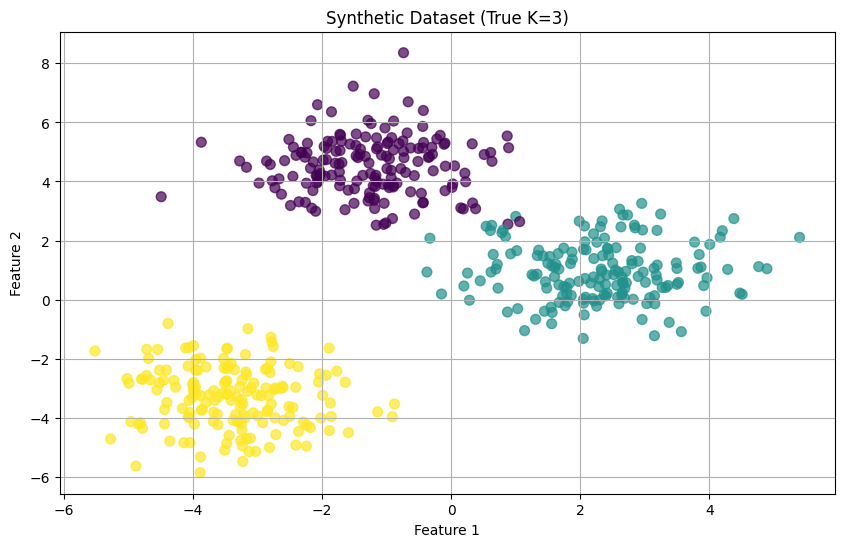

In [57]:
# Ground Truth: We set the true number of clusters (n_centers) to 3
TRUE_K = 3

X, true_labels = make_blobs(
    n_samples=500,
    centers=TRUE_K,
    cluster_std=1,
    center_box=(-5.0,5.0),
    random_state=42
)

plt.figure(figsize=(10, 6))
# Using true_labels for color to show the ground truth
plt.scatter(X[:, 0], X[:, 1], c=true_labels, cmap='viridis', s=50, alpha=0.7)
plt.title(f'Synthetic Dataset (True K={TRUE_K})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

## Training with K-Means

K-Means is a partitioning algorithm for clustering. The idea of the algorithm is the following:


1.   Generate $K$ initial points in the space. These point will be the initial centroids. (The centroids of a cluster is just the mean of the examples
assigned to the k-th cluster)
2.   Assign each example to the cluster whose centroid is the closest
according to the considered similarity or distance.
3.   Then recalculate the position of the $K$ centroids as means of the vectors of the examples belonging to the respective clusters
4.   Repeat steps 2 and 3 until the centroids stabilize.

Actually the objective function that K-Means is trying to minimize is the following:
$$V(X,\gamma)=\sum_{k=1}^K\sum_{i:\gamma(x_i)=k}||\mathbf{x}_i-c_k||^2$$

where $c_k$ is the centroid of $k$-th cluster, and $\gamma$ is the assignment function that maps every examples in $X$ into one of the $K$ clusters.

Knowing that the ground truth number of clusters is $K=3$, we will now execute the K-Means clustering algorithm across a variety of potential cluster counts, ranging from $K=2$ to $K=10$. For each of these resulting clusterings, we will calculate some evaluation metrics.

We expect that the clustering solution where $K=3$ will produce the better results across all metrics. Let's see if this will be confirmed.

### Evaluation Metrics

Internal metrics: they are crucial when ground truth labels are not available. In this notebook we will see ```davies_bouldin_score```, ```silhouette_score``` and ```calinski_harabasz_score``` that are all available in sklearn.

External metrics: in this case the ground truth labels need to be available because we are comparing them with the produced clustering. In this notebook we will see ```adjusted_rand_score``` (Adjusted RandIndex) available in sklearn.

In [58]:
# store metrics for further analysis
ari_scores = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for k in range(2,11):
    # K-Means Clustering
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(X)

    # ari requires the external ground truth
    ari = adjusted_rand_score(true_labels, cluster_labels)
    ari_scores.append(ari)

    # Silhoutte score
    sil_score = silhouette_score(X, cluster_labels)
    silhouette_scores.append(sil_score)

    # Davies-Bouldin Index
    db_score = davies_bouldin_score(X, cluster_labels)
    davies_bouldin_scores.append(db_score)

    # Calinski-Harabasz Index
    ch_score = calinski_harabasz_score(X, cluster_labels)
    calinski_harabasz_scores.append(ch_score)

    print(f"K={k}: ARI={ari:.4f}, Sil={sil_score:.4f}, DB={db_score:.4f}, CH={ch_score:.4f}")

K=2: ARI=0.5690, Sil=0.6193, DB=0.5440, CH=930.4695
K=3: ARI=0.9821, Sil=0.6886, DB=0.4410, CH=2073.7770
K=4: ARI=0.8606, Sil=0.5615, DB=0.8477, CH=1579.1456
K=5: ARI=0.8066, Sil=0.5506, DB=0.7448, CH=1348.7097
K=6: ARI=0.6620, Sil=0.4263, DB=0.9263, CH=1304.1850
K=7: ARI=0.5214, Sil=0.3384, DB=1.0749, CH=1275.3611
K=8: ARI=0.4528, Sil=0.3486, DB=0.9459, CH=1277.9661
K=9: ARI=0.3924, Sil=0.3375, DB=0.9439, CH=1241.7738
K=10: ARI=0.3636, Sil=0.3340, DB=0.9196, CH=1200.5493


## Interpretation of metrics and results

Now we will dive deeper into each of the metric that we collected before, one after the other, to see if we can achieve the best evaluation when $K=3$.

In [59]:
def plot_metric(metric_scores, title, color='red'):
  plt.plot(range(2,11), metric_scores, marker='o', linestyle='-', color=color)
  plt.axvline(x=TRUE_K, color='gray', linestyle='--', label=f'True K = {TRUE_K}')
  plt.legend()
  plt.title(title)
  plt.xlabel('Number of Clusters (K)')
  plt.ylabel('Score')
  plt.grid(True, alpha=0.4)
  plt.show()

#### Adjusted RandIndex (External metrics)

RandIndex is very similar to the notion of accuracy used in classification,
considering for each pair of examples whether they have been
correctly distributed in the clusters (i.e. they are in the same cluster if
and only if they are of the same class in the ground truth).

When evaluating with Adjusted RandIndex (ARI), then the raw RI is “adjusted for chance” into the ARI score using the following scheme:
$$\text{ARI} = \frac{\text{RI} - \text{Expected\_RI}}{\max(\text{RI}) - \text{Expected\_RI}}$$

Adjusted RandIndex score interpretation (range between ```-0.5``` and ```1.0```):


*   A ```score=1.0``` is a perfect match: the clustering solution is identical to the ground truth (up to a permutation of cluster labels).
*   A score near to ```0.0``` means that the clustering result is no better than random labeling, regardless of the number of clusters or samples.
*   A ```score=-0.5``` is when we have very discordant clustering.


In our case as expected, ARI is almost 1 when $K=3$ (it is not 1 because there was some outliers in the dataset for each clusters). Therefore this means that the algorithm was very effective when grouping the examples.

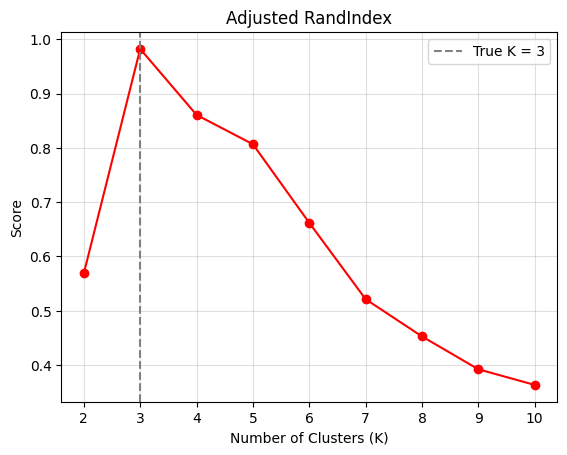

In [60]:
plot_metric(ari_scores, 'Adjusted RandIndex')

#### Silhoutte Coefficient (Internal metric)

The Silhoutte Coefficient is calculated for each example. ```silhouette_scores``` in sklearn is just the mean Silhouette Coefficient of all samples.

In particular the Silhouette Coefficient for a sample is:
$$s_i = \frac{b_i - a_i}{\max(a_i, b_i)}$$
where we have:

- Cohesion ($a_i$): The average distance of point $i$ to all other points within its own cluster.
- Separation ($b_i$): The average distance of point $i$ to all points in the next nearest cluster (the cluster to which $i$ does not belong but is closest to).

Silhoutte Coefficient value interpretation (range between ```-1.0``` and ```1.0```):

- A value of ```1``` is ideal, signifying excellent separation and compactness.
- Values approaching ```0``` indicate poor separation, suggesting the clusters are overlapping.
- Negative values approaching to ```-1``` indicate that a sample has been assigned to the wrong cluster, as a different cluster is more similar.

In our case, we have the highest value for $K=3$, as it should.

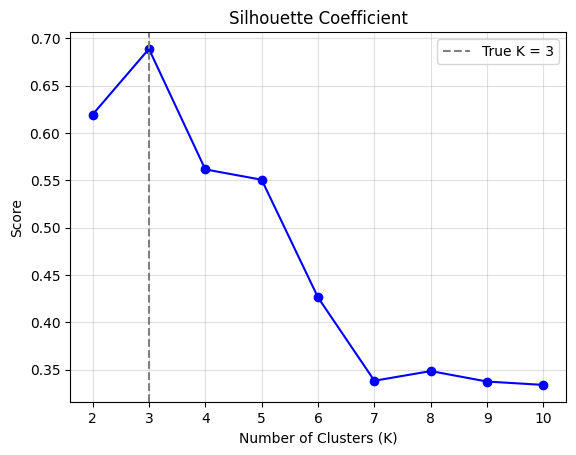

In [61]:
plot_metric(silhouette_scores, 'Silhouette Coefficient', 'blue')

#### Davies-Bouldin Index (Internal metric)

The Davies-Bouldin score is calculated as the average similarity measure, $R_{i,j}$, between each cluster $C_i$ and the cluster $C_j$ that is most similar to it.

Here similarity is the ratio of within-cluster distances to between-cluster distances. The similarity measure $R_{i,j}$ compares two clusters, $C_i$ and $C_j$:

$$R_{i,j} = \frac{s_i + s_j}{d(c_i, c_j)}$$

In general for a cluster $C_k$ we have that $s_k$ is the average distance between each point in cluster $C_k$ and the centroid $c_k$ of that cluster. A smaller $s_k$ indicates a more compact cluster. Meanwhile the term $d(c_i, c_j)$ is the distance between the centroids $c_i$ and $c_j$ of the two clusters, $C_i$ and $C_j$.

For each cluster $C_i$, we must find the other cluster $C_j$ (where $i \neq j$) that is most similar to it. The most similar cluster is the one that produces the maximum value for the ratio $R_{i,j}$. This maximum similarity is denoted as $D_i$ (with $k$ being the number of clusters):

$$D_i = \max_{j=1, \dots, k, j \neq i} R_{i,j}$$

Then the Davies-Bouldin Index ($DBI$) is calculated as the average of all the $D_i$ values:

$$DBI = \frac{1}{k} \sum_{i=1}^{k} D_i$$

The minimum score is ```0```, with lower values indicating better clustering.  In fact for a value closer to ```0``` the clusters will be compact and well-separated. Meanwhile for higher values the clusters will be highly scattered or heavily overlapping.

In our case, we have the lowest value for $K=3$, as expected. Even though is not very low but it could be because in the dataset the original clusters we generate were not very far apart.

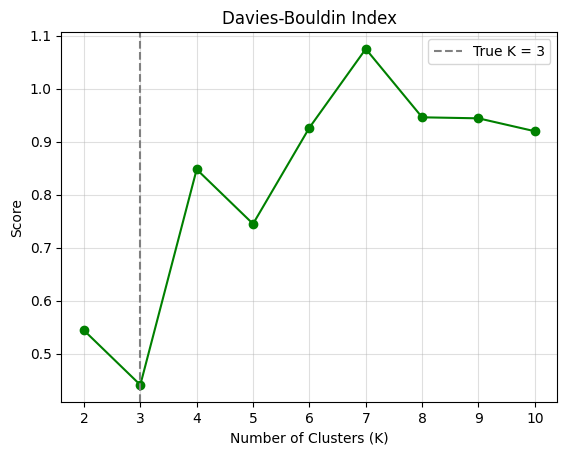

In [62]:
plot_metric(davies_bouldin_scores, 'Davies-Bouldin Index', 'green')

#### Calinski-Harabasz Index (Internal metric)

The Calinski-Harabasz Index (CHI) score is also known as the Variance Ratio Criterion.

It is defined as the ratio of the between-cluster dispersion to the within-cluster dispersion.

$$CHI = \frac{\text{BCSS} / (k - 1)}{\text{WCSS} / (N - k)}$$

where:

- $BCSS$ (Between-Cluster Sum of Squares): it is the weighted sum of squared distances between each cluster centroid and the overall centroid of the data.

- $WCSS$ (Within-Cluster Sum of Squares): it is the sum of squared distances between each data point and its assigned cluster centroid.

- $N$ is the number of points and $k$ the number of clusters.

A higher value of the Calinski-Harabasz Index generally corresponds to a model with better defined clusters (clusters that are dense and well-separated).

In our case we can achieved the highest value for the Calinski-Harabasz Index when $K=3$, as expected.

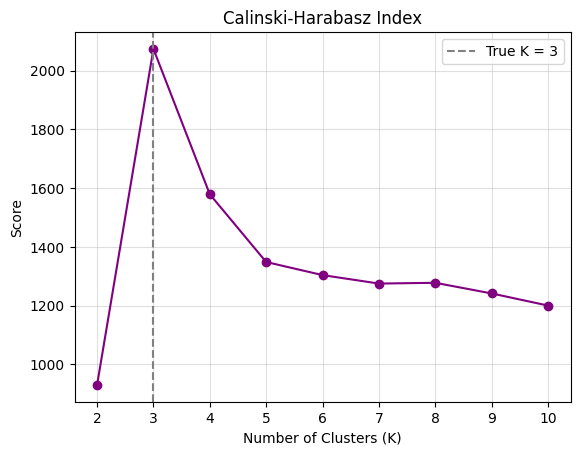

In [63]:
plot_metric(calinski_harabasz_scores, 'Calinski-Harabasz Index', 'purple')

## Conclusion and data visualization

To conclude we can visualize the result of the K-Means model that we fitted before, the result of the clustering should be very similar (almost identical, but we have some outliers) to the labelings of the syntethic dataset we generate before.

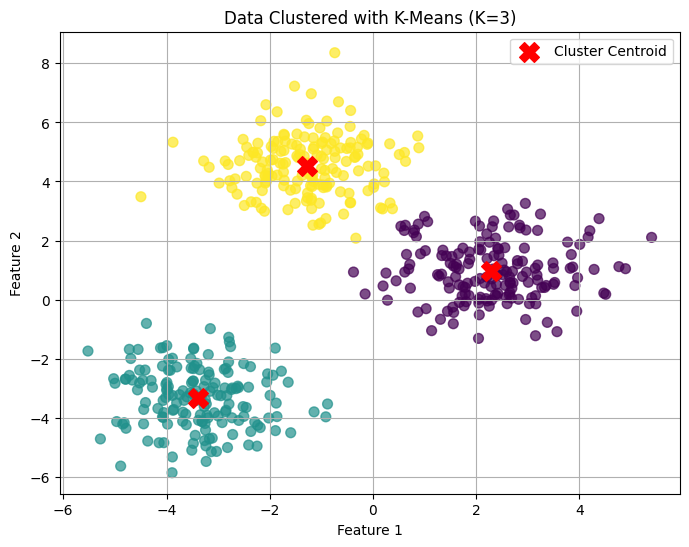

In [64]:
kmeans_optimal = KMeans(n_clusters=TRUE_K, random_state=42, n_init='auto')
final_labels = kmeans_optimal.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=final_labels, cmap='viridis', s=50, alpha=0.7)
plt.scatter(kmeans_optimal.cluster_centers_[:, 0], kmeans_optimal.cluster_centers_[:, 1],
            marker='X', s=200, c='red', label='Cluster Centroid')
plt.title(f'Data Clustered with K-Means (K={TRUE_K})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

## Use of AI assistant
I used AI assistant to help me with english language in order to write better some sentences.

## References

Slide Lez18 - Clustering

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.davies_bouldin_score.html

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.calinski_harabasz_score.html

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

https://medium.com/@vladimir-artus/%D1%81lustering-metrics-evaluate-the-complex-make-it-simple-6ae70c0f164b